In [ ]:
import numpy as np # para manipular arrays y realizar operaciones matematicas
import pandas as pd # para manipular dataframes y realizar operaciones de limpieza y analisis de datos
import matplotlib.pyplot as plt # para crear graficos y visualizaciones de datos
import seaborn as sns # para crear graficos y visualizaciones de datos mas avanzados y atractivos
import scipy as sp # general de scipy, aunque lo usaremos principalmente para estadistica
import scipy.stats as stats # para realizar pruebas de hipotesis y analisis estadistico
import pingouin as pg # para realizar pruebas de hipotesis y analisis estadistico de manera mas facil y rapida
import statsmodels.api as sm # para realizar pruebas de hipotesis y analisis estadistico de manera mas avanzada

# Probabilidad y estadística

## Principios de estadística

La estadística según wikipedia es:
> La estadística es la disciplina que estudia la variabilidad de los fenómenos y los procesos aleatorios que la generan, conforme a las leyes de la probabilidad.

Por lo cual veremos en esta sección diferentes formas de describir nuestros datos.

### Análisis de Datos Exploratorio y Estadística descriptiva

Para esta sección partiremos con las primeras definiciones. En estadística los datos se denominan `muestras`, los cuales vienen de una `población` que los contiene. Pensémoslo como analizar una muestra de 10 tortugas de una población de cientos de ellas. Nuestro objetivo final es poder sacar conclusiones sobre toda la población a partir de esas 10 tortugas.

Asumamos que desde una población se obtuvieron los siguientes datos aleatorios.

In [33]:
x_muestra = np.random.randn(100) # 100 numeros aleatorios de una distribucion normal 
# veremos más adelante que es una distribucion normal y como generar numeros aleatorios de esta distribucion,

Antes de cualquier tipo de análisis, es primordial visualizar los datos. Para esto existen diferentes tipos de gráficos; los principales son:
1. Histograma.
2. Boxplot.
3. Violinplot.

Estos se utilizan para ver cómo se distribuyen los datos: si hay alguna concentración en alguna zona o si existe algún tipo de sesgo.

El siguiente código tiene la estructura principal de un gráfico en `python`. Es recomendable que lo intenten por su cuenta y vean cómo funciona.

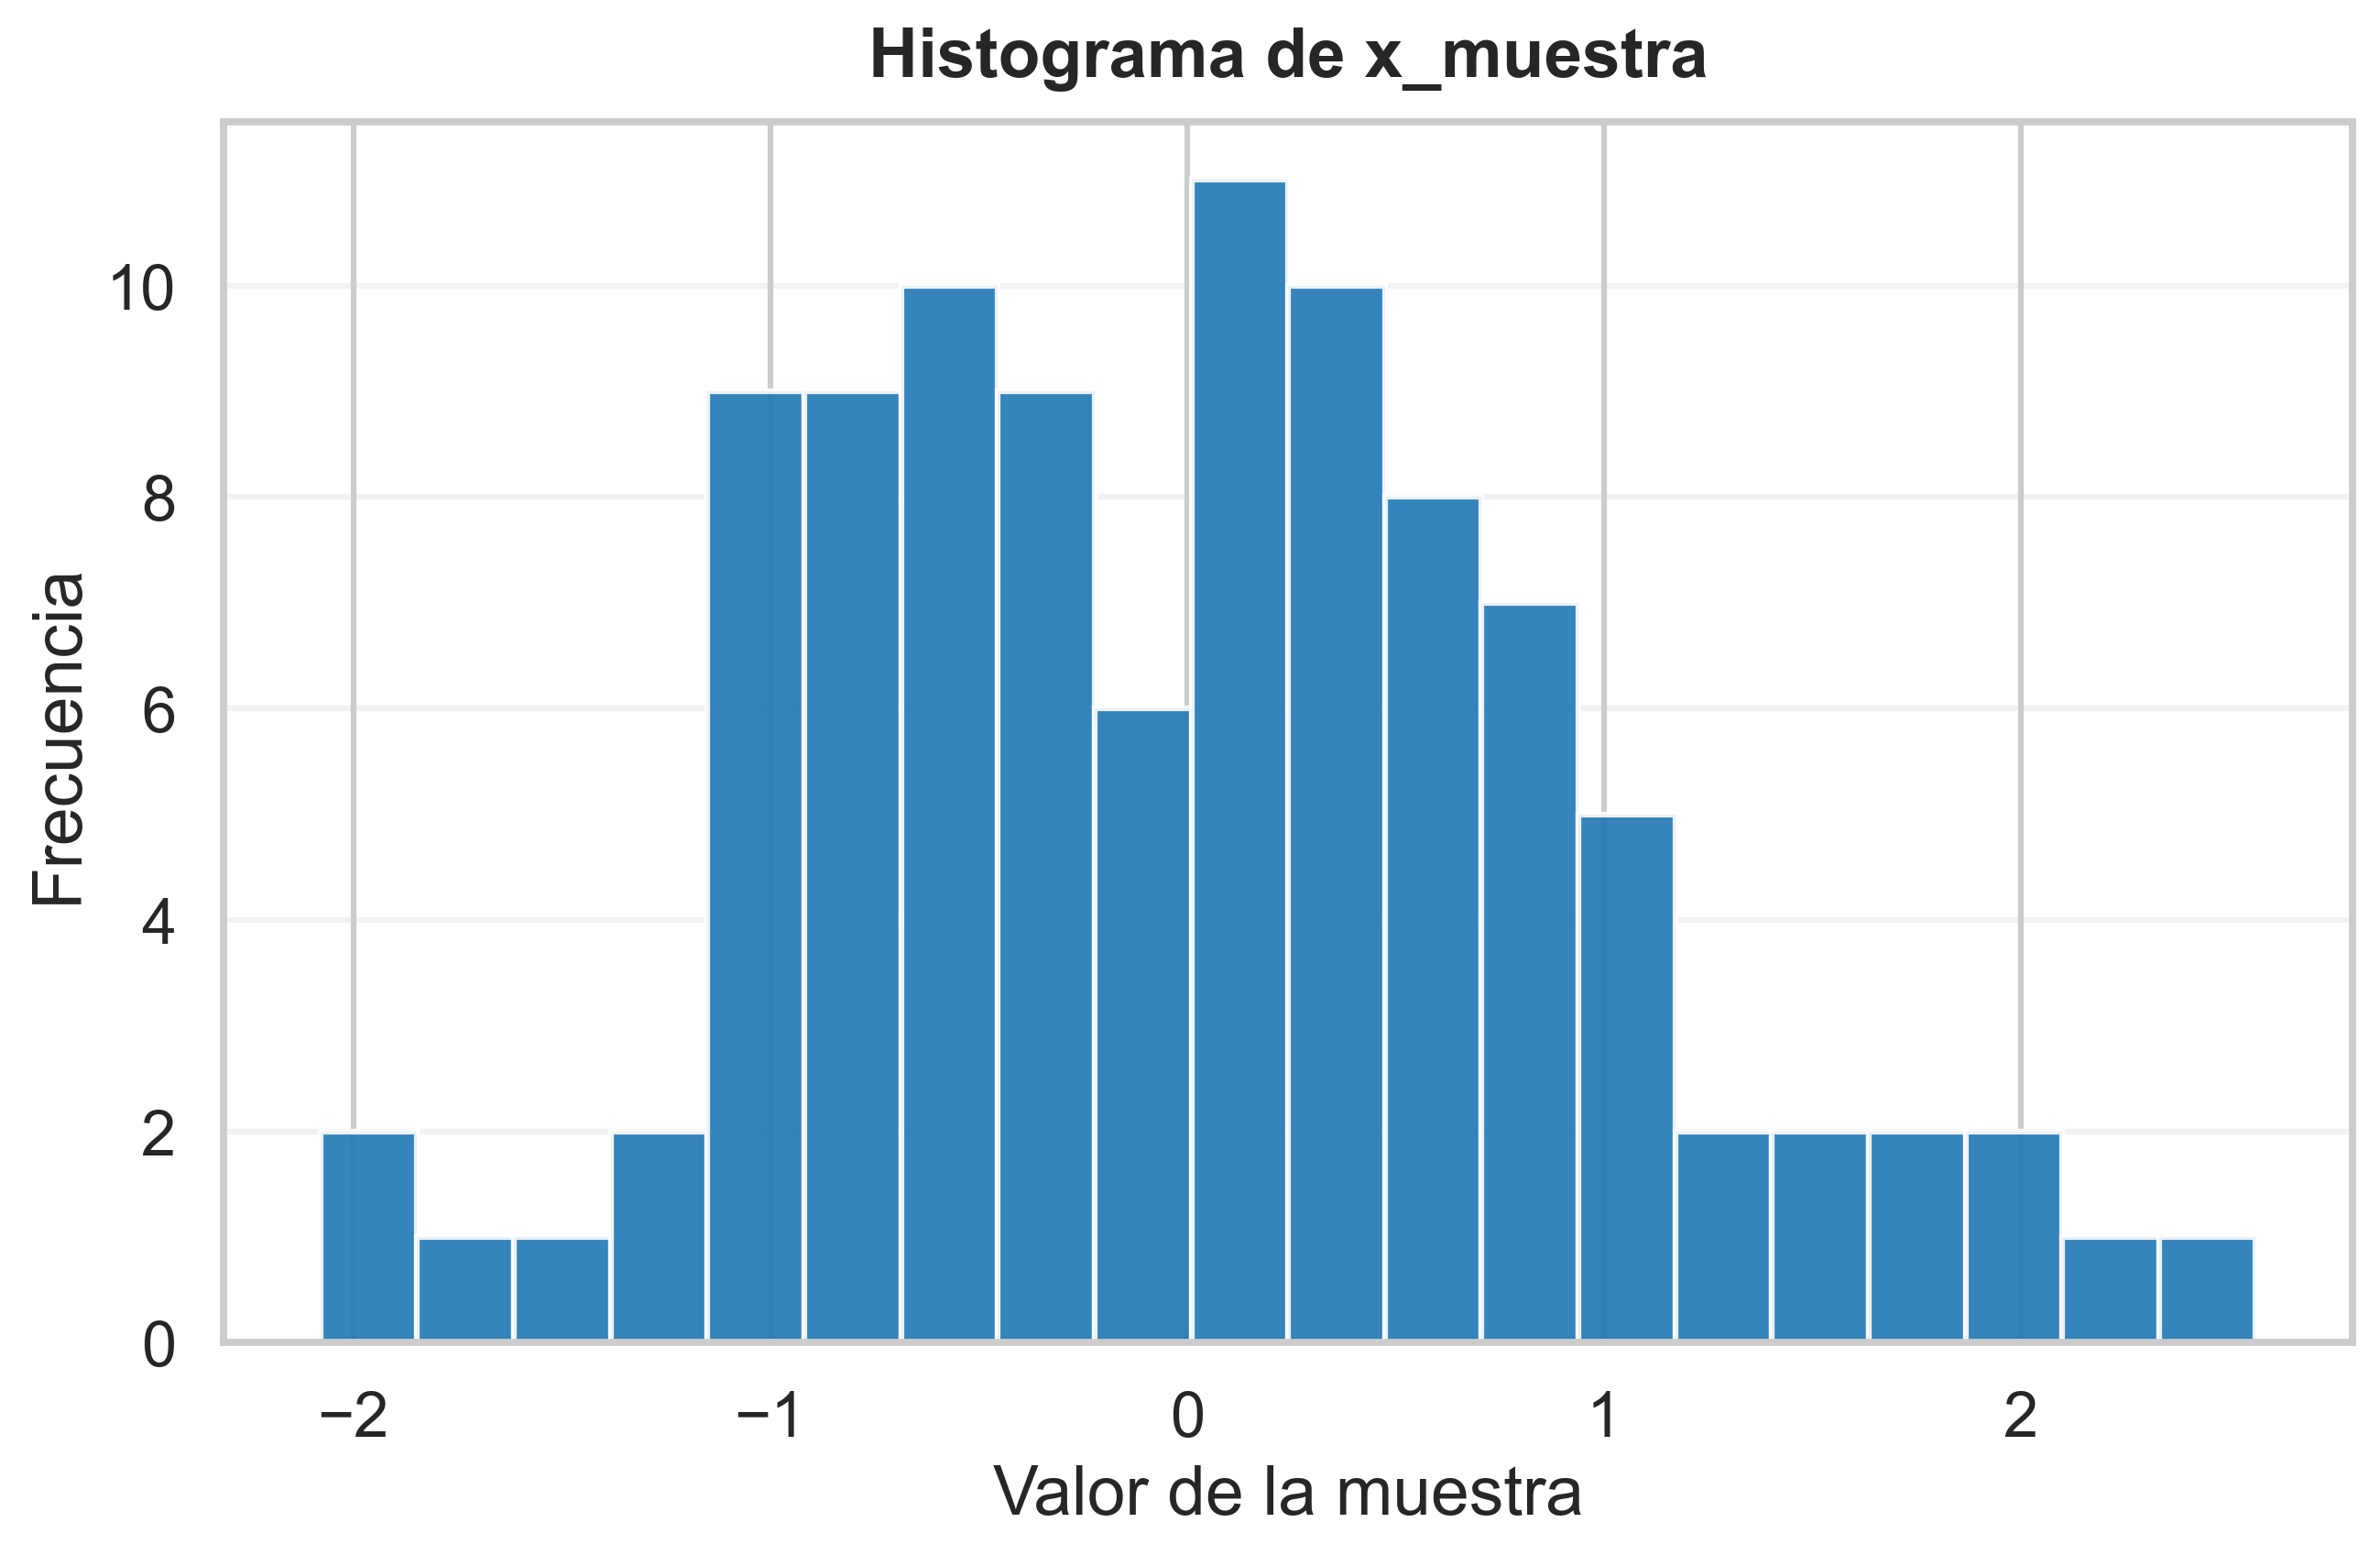

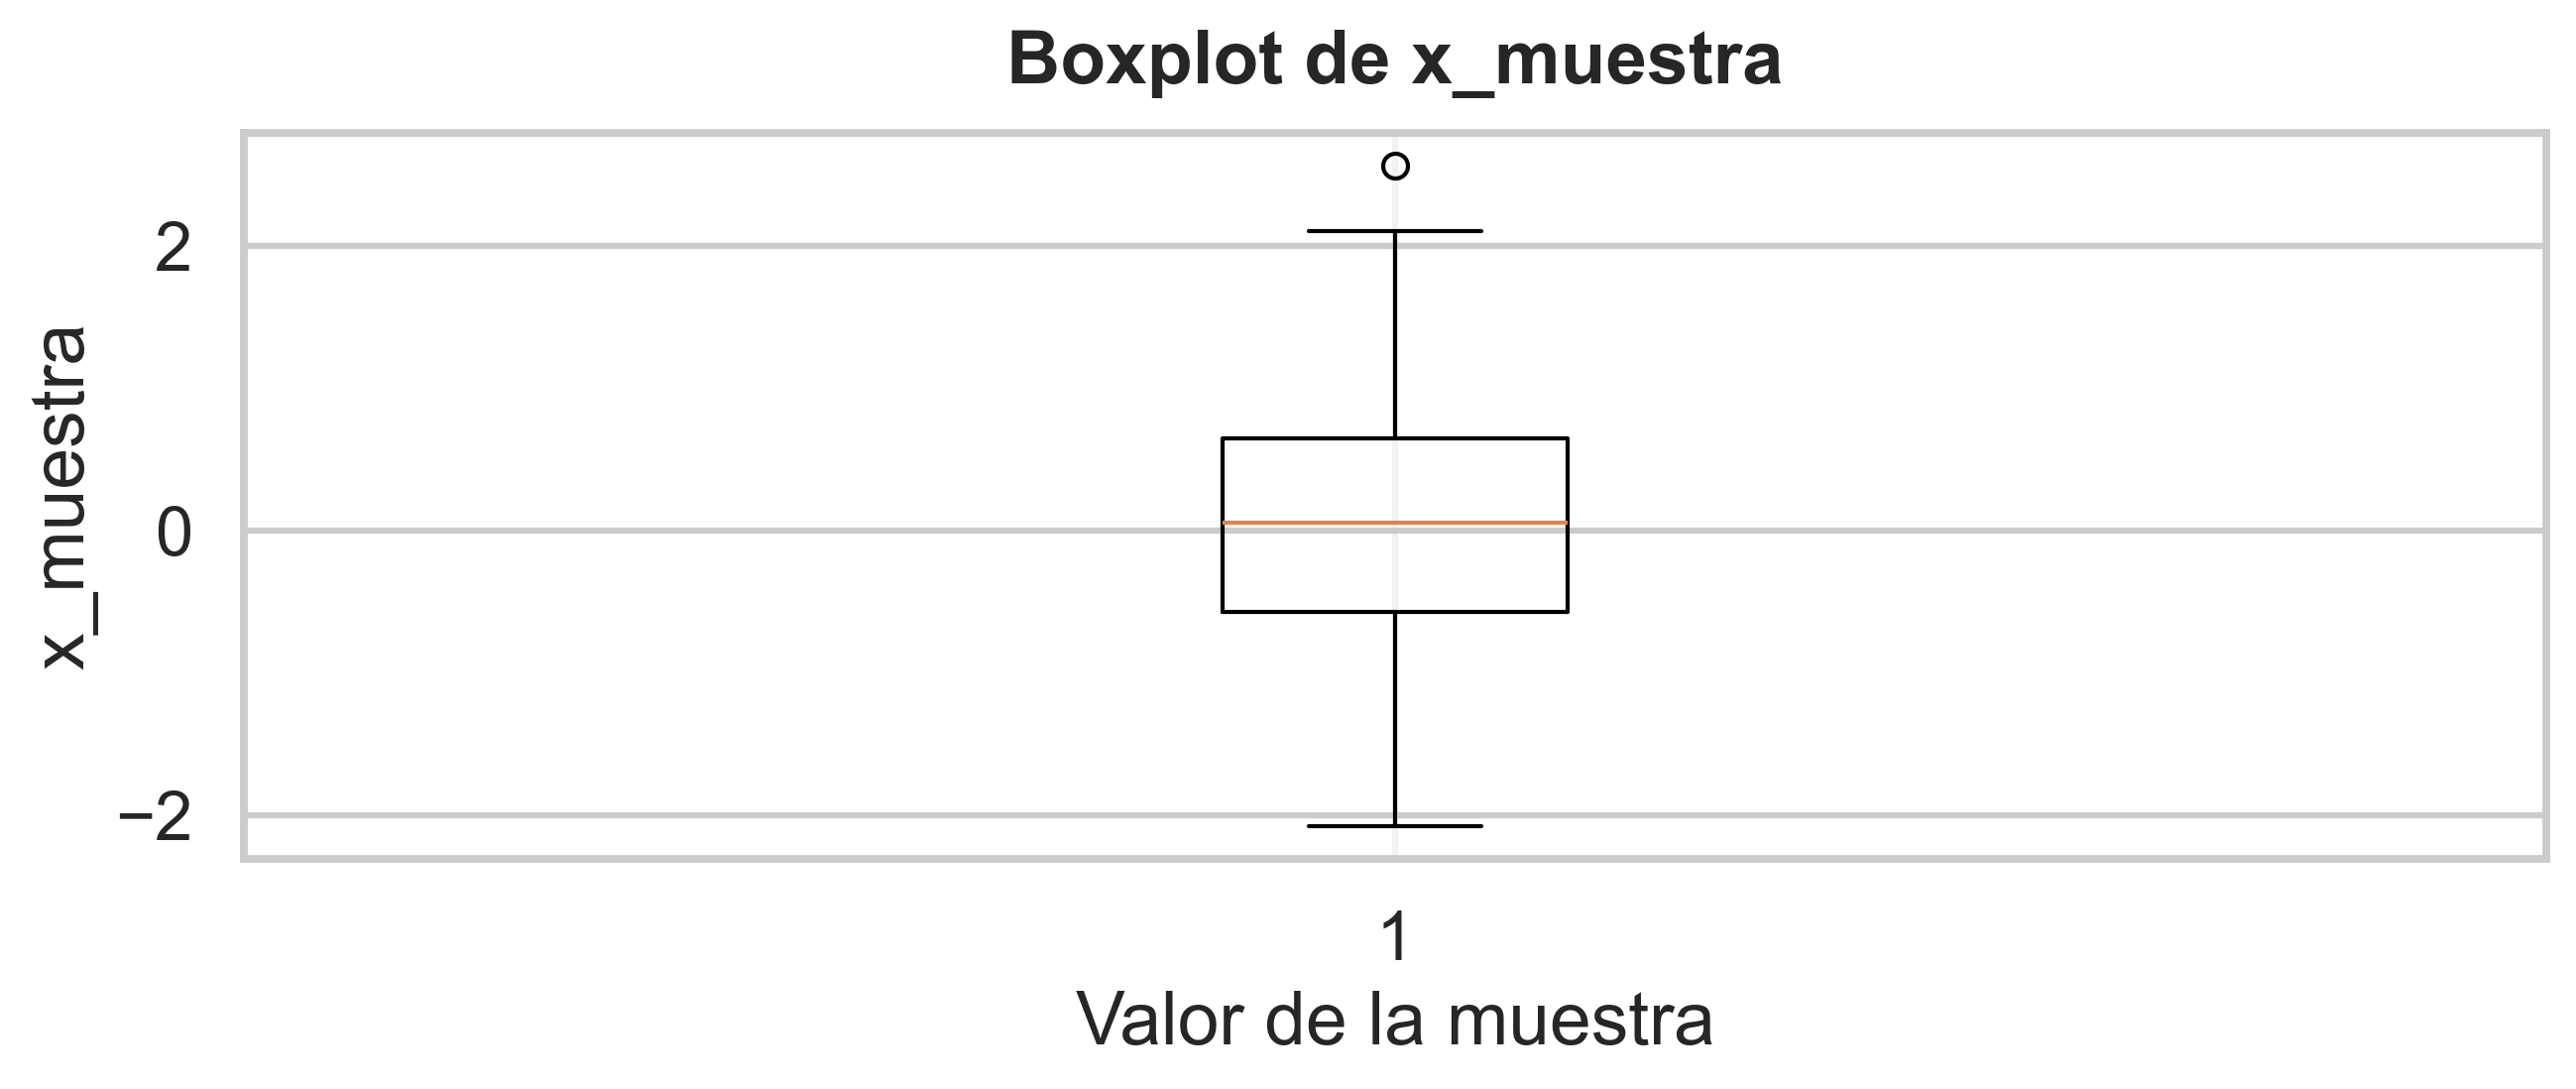

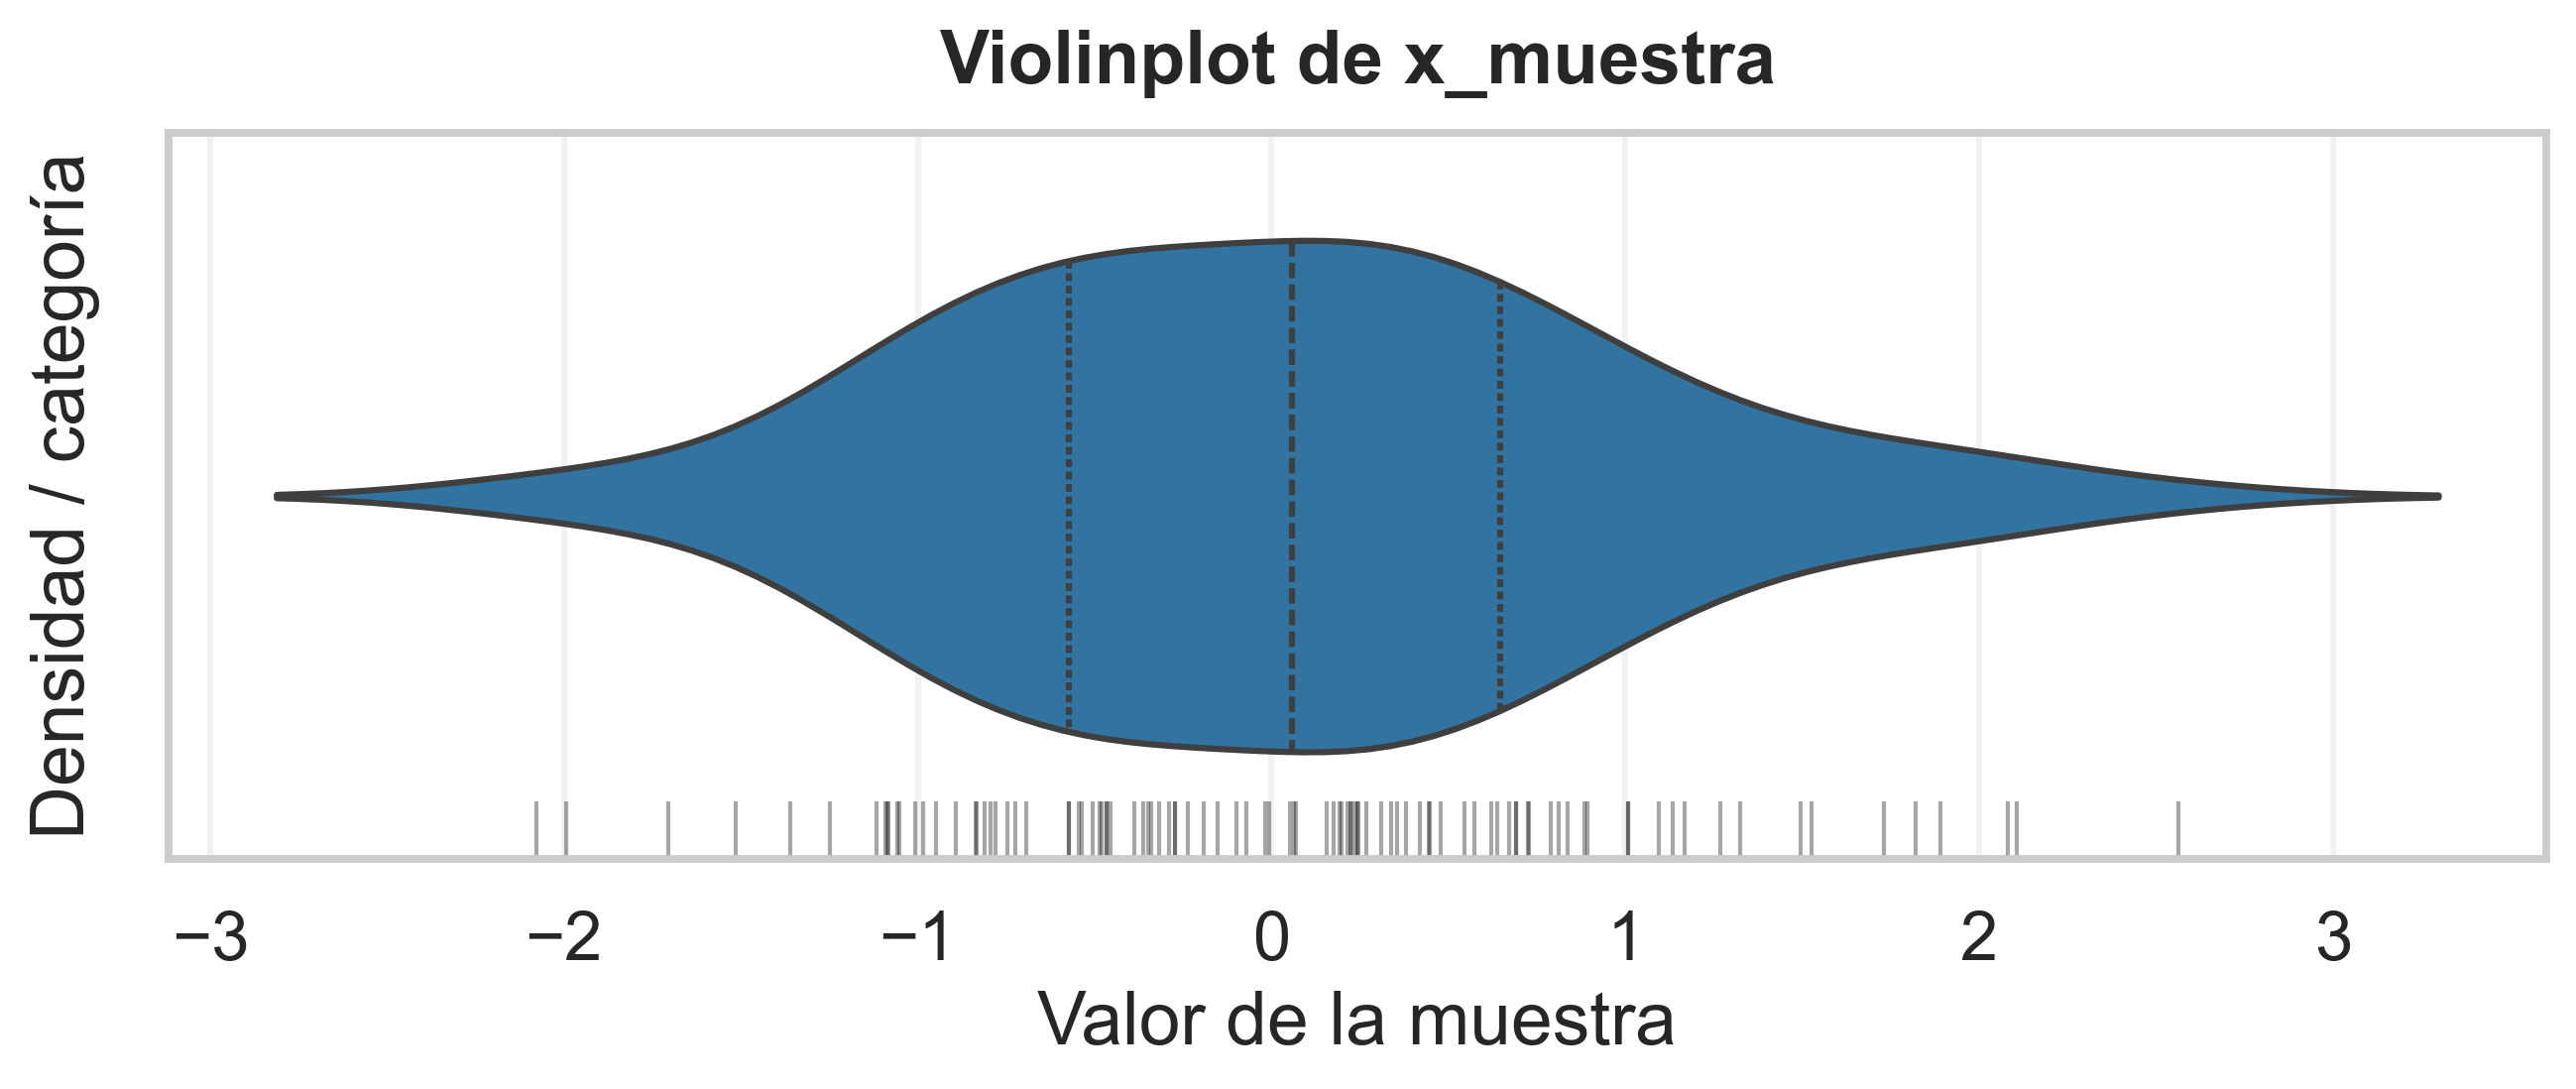

In [34]:

# Definimos un estilo general para que todos los gráficos tengan una estética consistente.
sns.set_theme(style="whitegrid", context="talk")


# -------------------------
# Histograma
# -------------------------

# Creamos la figura y el eje con tamaño y resolución adecuados para buena calidad.
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

# Dibujamos el histograma: color suave + borde para distinguir mejor las barras.
ax.hist(
    x_muestra, # los datos a graficar
    bins=20, # número de barras (bins) para mostrar la distribución con suficiente detalle
    color="tab:blue", # color de las barras
    edgecolor="white", # color del borde de las barras para mejorar contraste
    alpha=0.9 # transparencia de las barras para que no se vean tan opacas
)

# Agregamos títulos y etiquetas descriptivas en ambos ejes.
ax.set_title("Histograma de x_muestra", pad=12, fontweight="bold")
ax.set_xlabel("Valor de la muestra")
ax.set_ylabel("Frecuencia")

# Mejoramos legibilidad con grilla horizontal.
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

# Opción para guardar la figura (descomentando la siguiente línea).
# fig.savefig("histograma_x_muestra.png", dpi=300, bbox_inches="tight")

plt.show()

# -------------------------
# Boxplot
# -------------------------

# Creamos una nueva figura para el boxplot.
fig, ax = plt.subplots(figsize=(9, 4), dpi=300)

# Dibujamos un boxplot horizontal y personalizamos sus elementos para mayor claridad visual.
ax.boxplot(
    x_muestra,
)


# Títulos y etiquetas descriptivas.
ax.set_title("Boxplot de x_muestra", pad=12, fontweight="bold")
ax.set_xlabel("Valor de la muestra")
ax.set_ylabel("x_muestra")

# Ajustes finales de estilo.
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()

# Opción para guardar la figura (descomentando la siguiente línea).
# fig.savefig("boxplot_x_muestra.png", dpi=300, bbox_inches="tight")

plt.show()

# -------------------------
# Violinplot
# -------------------------

# Creamos una nueva figura para el violinplot.
fig, ax = plt.subplots(figsize=(9, 4), dpi=300)

# Dibujamos el violinplot con cuartiles internos para mostrar estructura de la distribución.
sns.violinplot(
    x=x_muestra, # los datos a graficar
    ax=ax, # el eje donde se dibujará el gráfico
    color="tab:blue", # color del violín para una apariencia suave y profesional
    inner="quartile", # muestra los cuartiles dentro del violín para facilitar interpretación de la distribución
    linewidth=1.5 # grosor del borde del violín para mejorar visibilidad y contraste
)

# Agregamos un rugplot para visualizar observaciones individuales sobre el eje x.
sns.rugplot(x=x_muestra, ax=ax, color="black", alpha=0.35, height=0.08)

# Títulos y etiquetas descriptivas.
ax.set_title("Violinplot de x_muestra", pad=12, fontweight="bold")
ax.set_xlabel("Valor de la muestra")
ax.set_ylabel("Densidad / categoría")

# Ajustes visuales finales.
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()

# Opción para guardar la figura (descomentando la siguiente línea).
# fig.savefig("violinplot_x_muestra.png", dpi=300, bbox_inches="tight")

plt.show()

Existen muchos otros tipos de gráficos, pero los iremos viendo a medida que avanza este torpedito.

Además de poder visualizar los datos, existen otros tipos de descriptores llamados *estadísticas descriptivas* (*descriptive statistics*), que resumen ciertas características de los datos.

La primera medida es la **media muestral**, también conocida como el promedio de la muestra. Esta nos indica la tendencia central de los datos.

> **Media muestral**
> Si $x_1, x_2, \ldots, x_n$ corresponden a una muestra de $n$ observaciones, la media muestral se define como:
> $$ \overline{x} = \frac{1}{n}\sum_{i=1}^{n} x_i $$

Otra medida importante es la **varianza muestral**. Esta nos indica qué tan dispersos están los datos: a menor varianza, los datos están más concentrados alrededor de la media, y viceversa.

> **Varianza muestral**
> Si $x_1, x_2, \ldots, x_n$ corresponden a una muestra de $n$ observaciones, la varianza muestral se define como:
> $$ s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \overline{x})^2 $$

Nótese que si las unidades de los datos son [$metros$], las unidades de $s^2$ serán [$metros^2$]. Por esto se define la **desviación estándar muestral** como $s = \sqrt{s^2}$, que queda en las mismas unidades que los datos.

Calcular estas cantidades en `Python` es sencillo usando `numpy` :D.

In [35]:
# usando los datos x_muestra
# la media muestral se calcula
media_muestral = np.mean(x_muestra)
# la varianza muestral se calcula
varianza_muestral = np.var(x_muestra, ddof=1) # ddof=1 para obtener la varianza muestral (dividir por n-1)
# la desviación estándar muestral se calcula
desviacion_estandar_muestral = np.std(x_muestra, ddof=1) # ddof=1 para obtener la desviación estándar muestral (dividir por n-1)
print('Media muestral:', media_muestral)
print('Varianza muestral:', varianza_muestral)
print('Desviación estándar muestral:', desviacion_estandar_muestral)



Media muestral: 0.04164604440956632
Varianza muestral: 0.8499679405042728
Desviación estándar muestral: 0.921937058862628


Estos valores pueden integrarse en los gráficos anteriores para hacerlos aún más informativos.

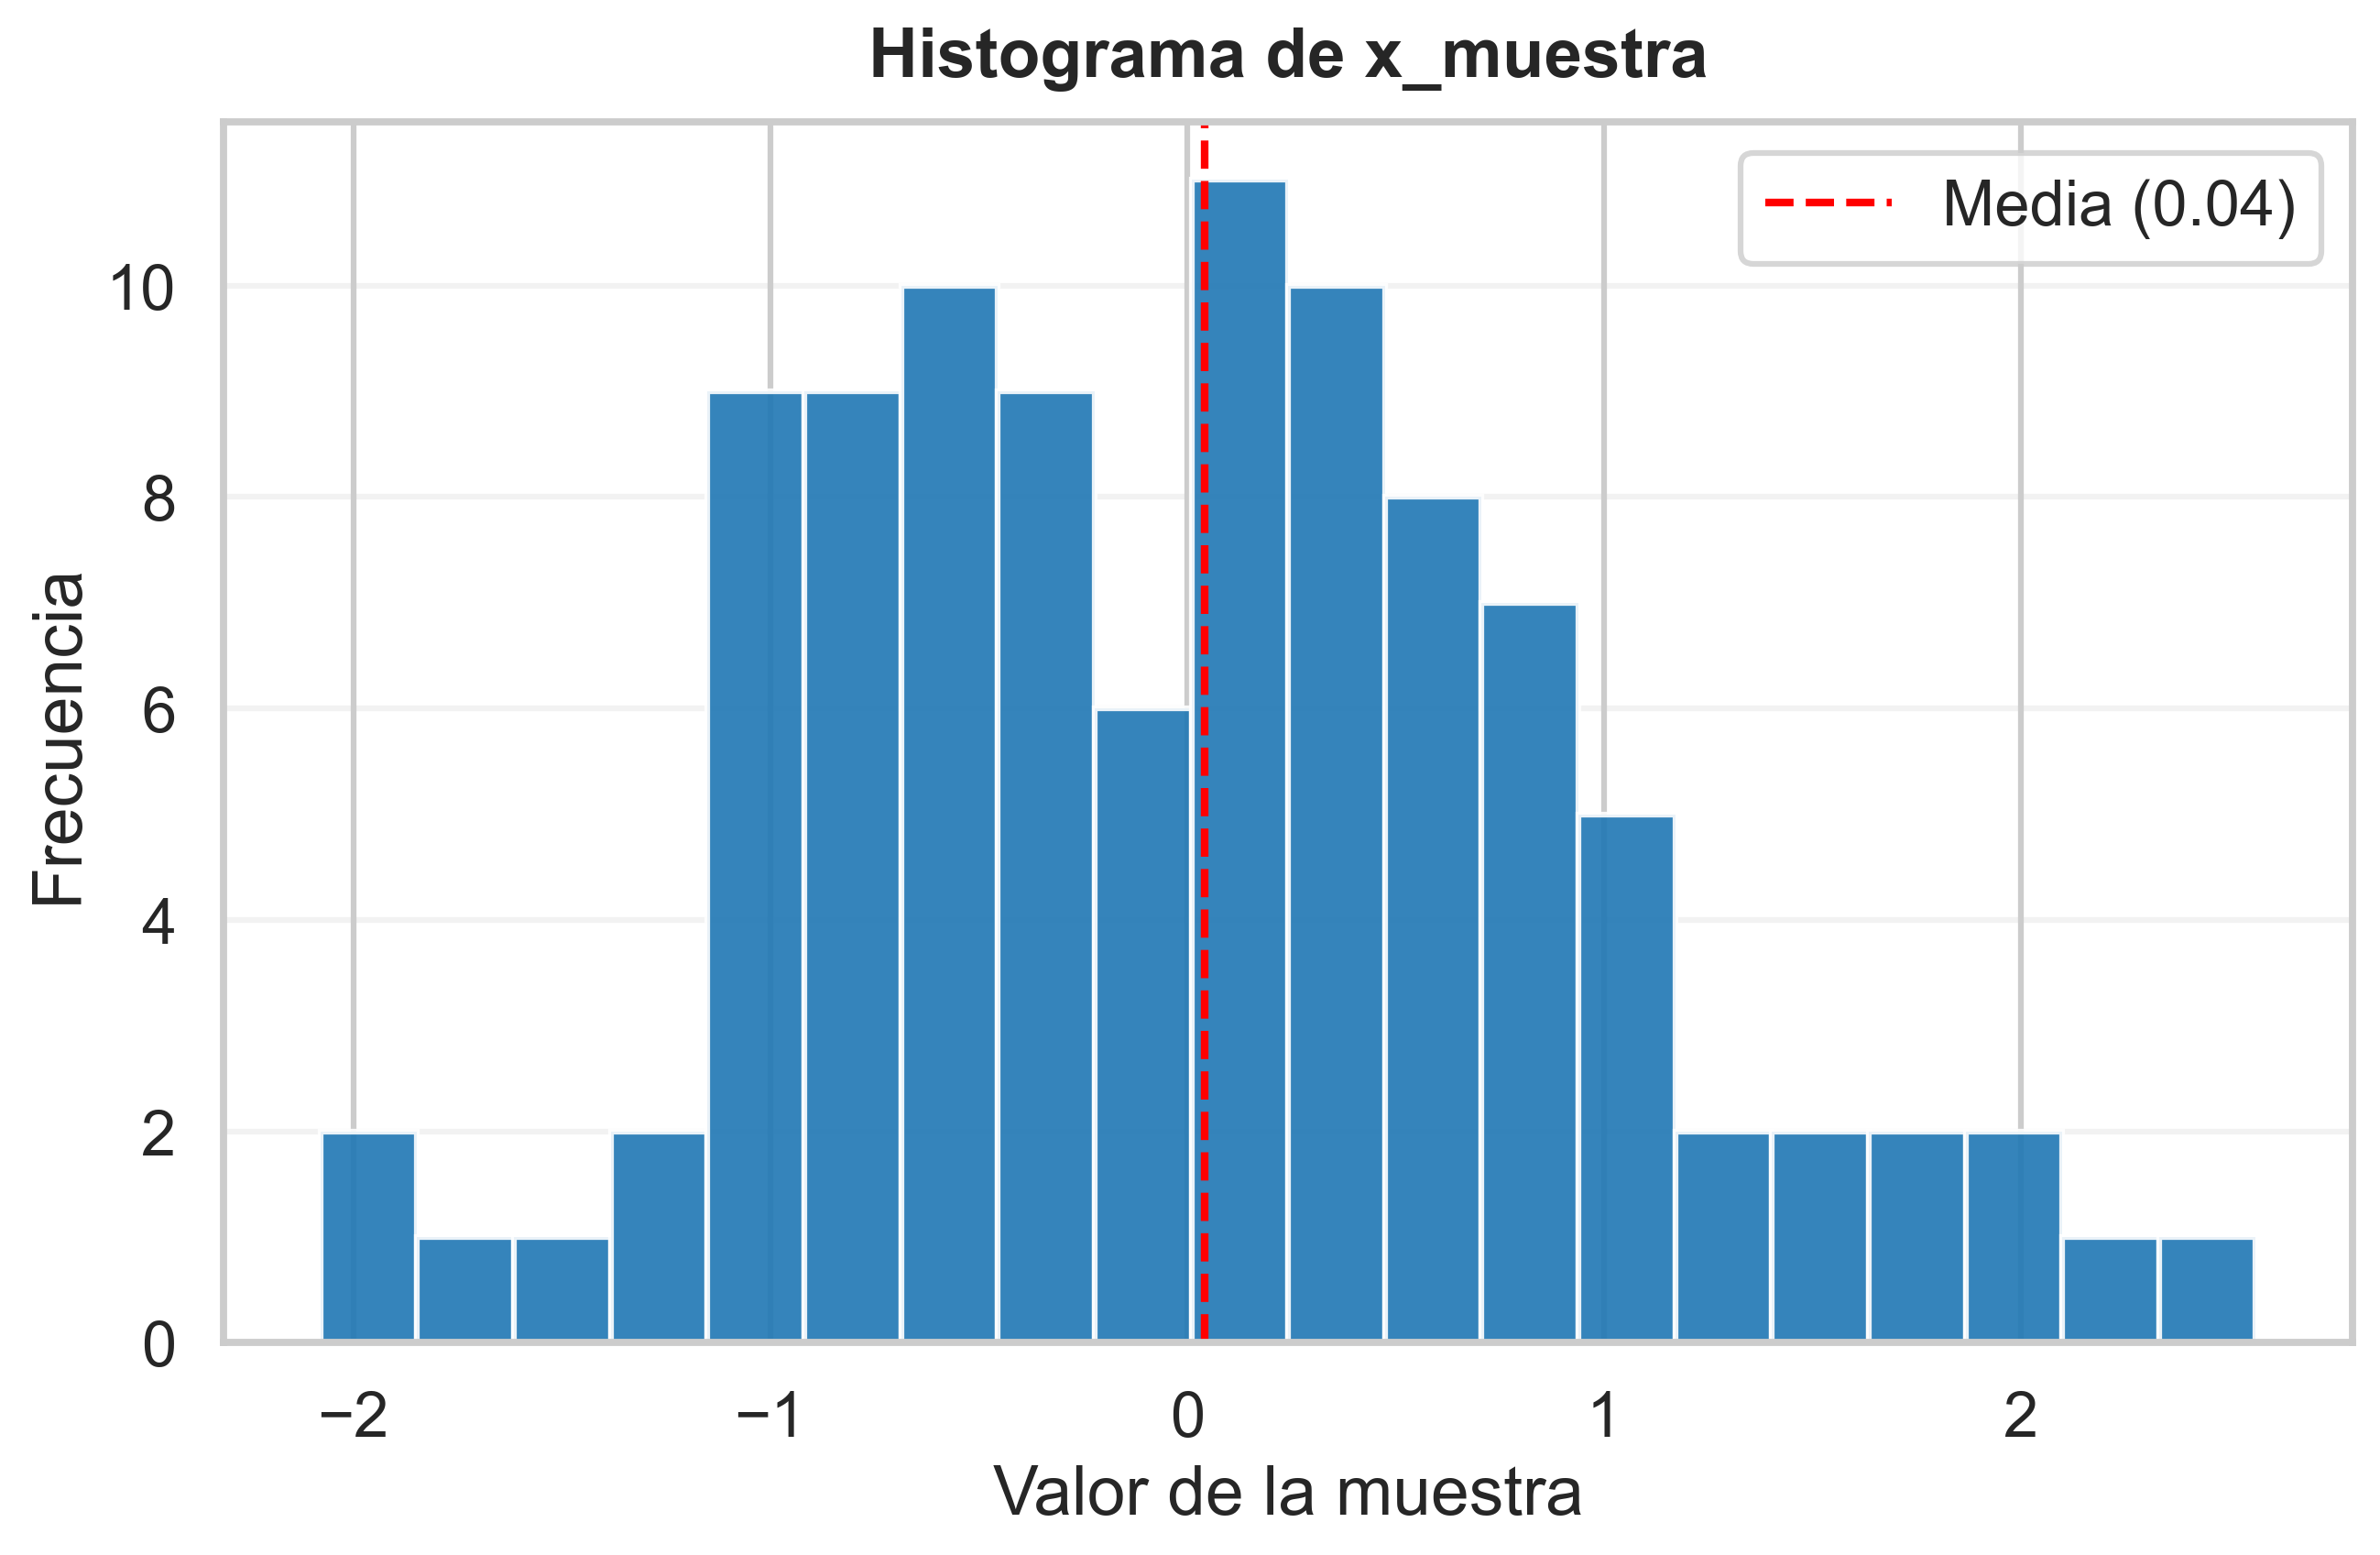

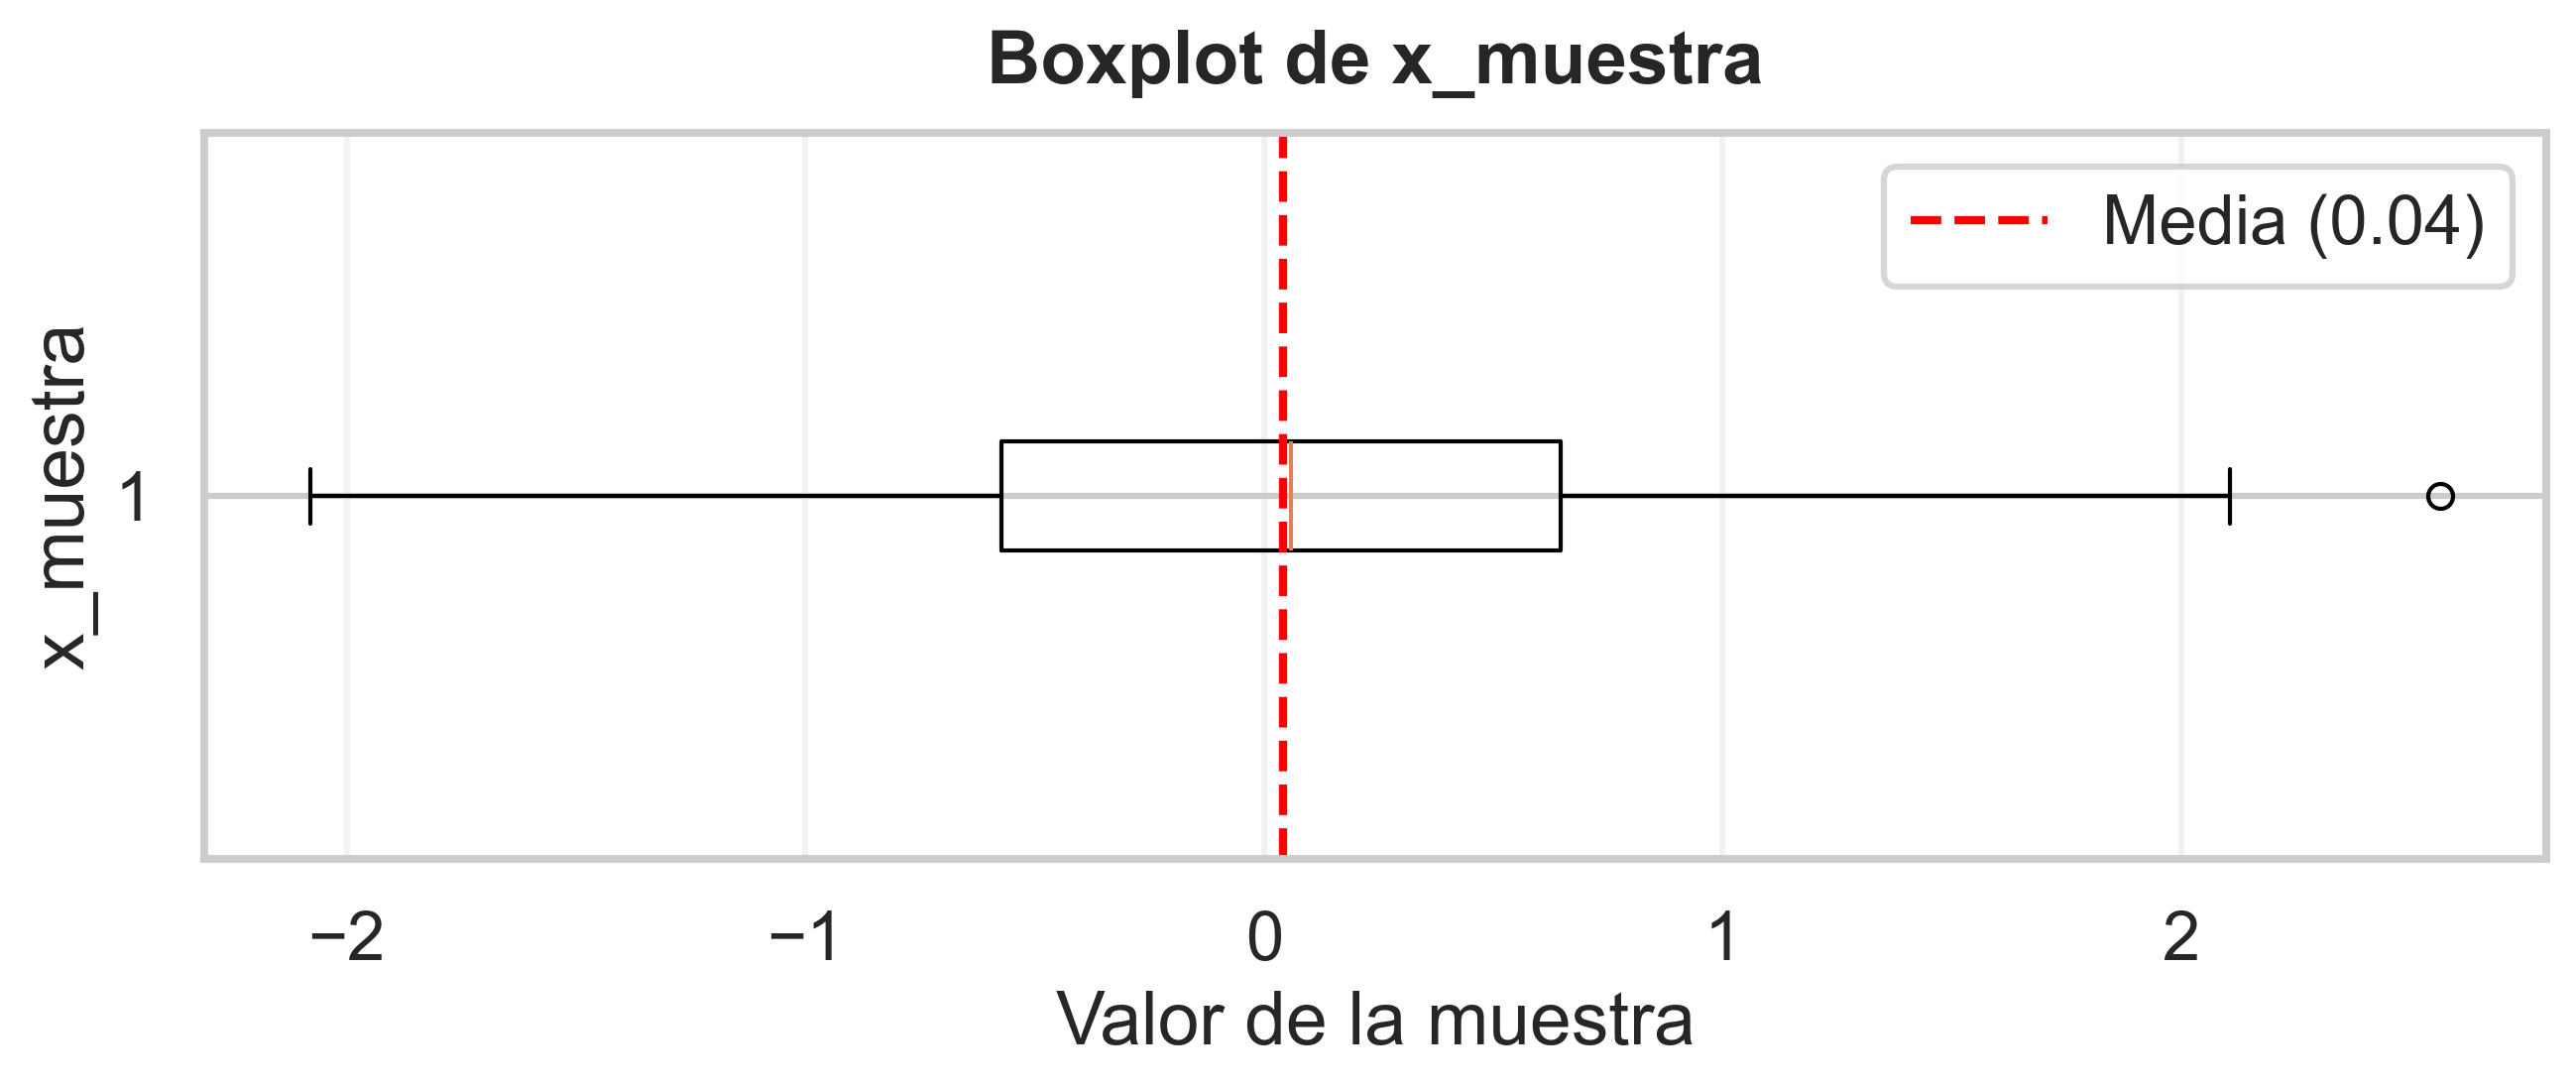

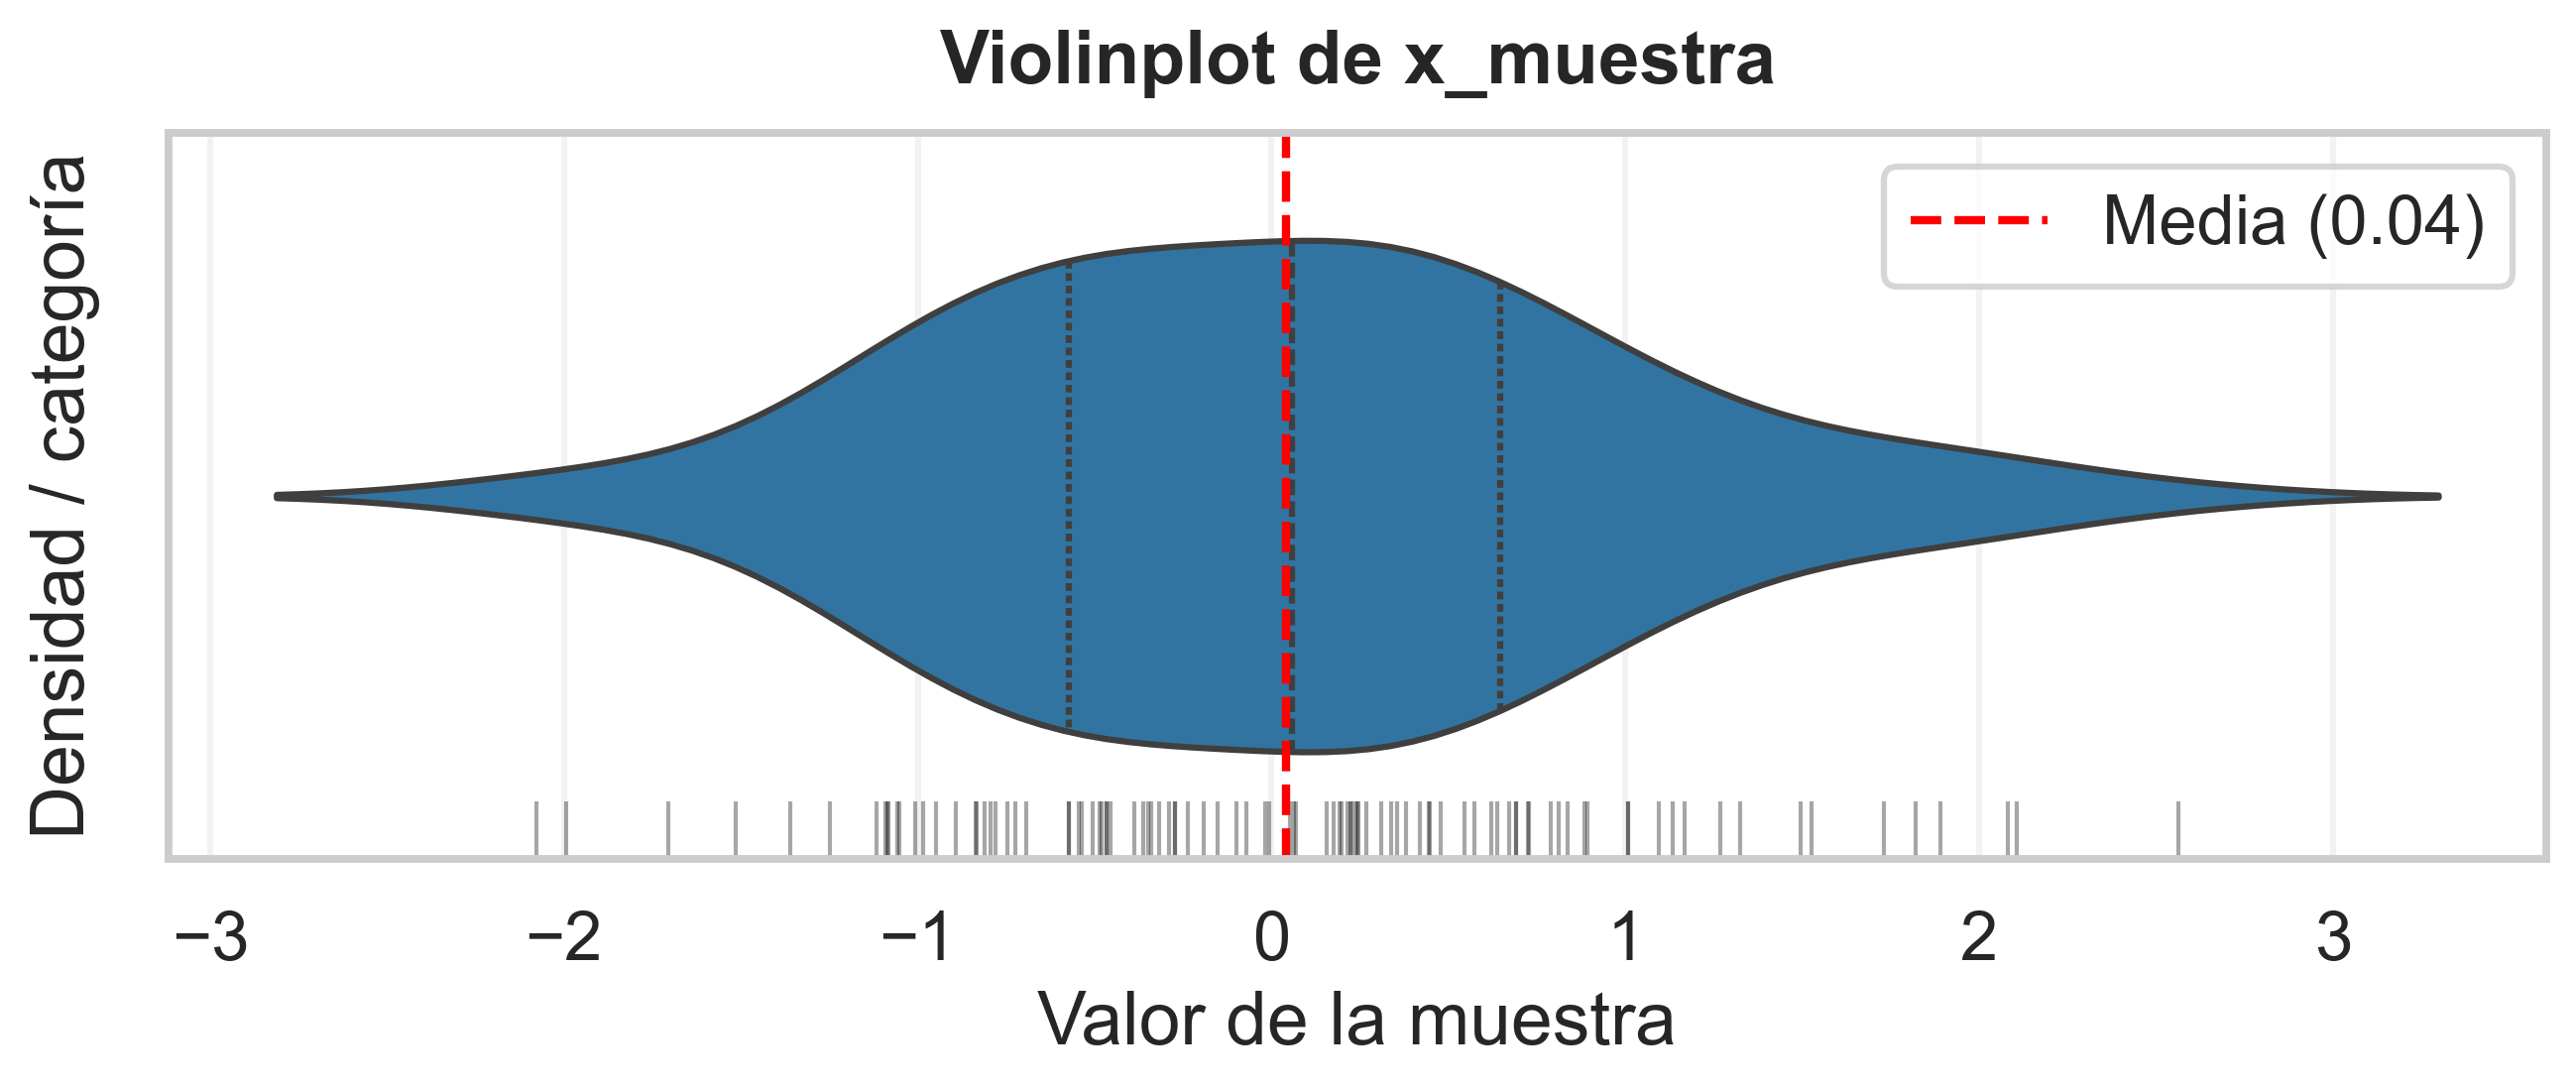

In [36]:

# Definimos un estilo general para que todos los gráficos tengan una estética consistente.
sns.set_theme(style="whitegrid", context="talk")


# -------------------------
# Histograma
# -------------------------

# Creamos la figura y el eje con tamaño y resolución adecuados para buena calidad.
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

# Dibujamos el histograma: color suave + borde para distinguir mejor las barras.
ax.hist(
    x_muestra, # los datos a graficar
    bins=20, # número de barras (bins) para mostrar la distribución con suficiente detalle
    color="tab:blue", # color de las barras
    edgecolor="white", # color del borde de las barras para mejorar contraste
    alpha=0.9 # transparencia de las barras para que no se vean tan opacas
)

# Agregamos una línea vertical para indicar dónde se encuentra la media
ax.axvline(x=media_muestral, color='red', linestyle='--', linewidth=2, label=f'Media ({media_muestral:.2f})')

# Agregamos títulos y etiquetas descriptivas en ambos ejes.
ax.set_title("Histograma de x_muestra", pad=12, fontweight="bold")
ax.set_xlabel("Valor de la muestra")
ax.set_ylabel("Frecuencia")

# Mejoramos legibilidad con grilla horizontal.
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=True)

plt.tight_layout()

# Opción para guardar la figura (descomentando la siguiente línea).
# fig.savefig("histograma_x_muestra.png", dpi=300, bbox_inches="tight")

plt.show()

# -------------------------
# Boxplot
# -------------------------

# Creamos una nueva figura para el boxplot.
fig, ax = plt.subplots(figsize=(9, 4), dpi=300)

# Dibujamos un boxplot horizontal y personalizamos sus elementos para mayor claridad visual.
ax.boxplot(
    x_muestra,
    vert=False # Se agrega explícitamente vert=False para que sea horizontal según el comentario
)

# Agregamos una línea vertical para indicar dónde se encuentra la media
ax.axvline(x=media_muestral, color='red', linestyle='--', linewidth=2, label=f'Media ({media_muestral:.2f})')

# Títulos y etiquetas descriptivas.
ax.set_title("Boxplot de x_muestra", pad=12, fontweight="bold")
ax.set_xlabel("Valor de la muestra")
ax.set_ylabel("x_muestra")

# Ajustes finales de estilo.
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=True)

plt.tight_layout()

# Opción para guardar la figura (descomentando la siguiente línea).
# fig.savefig("boxplot_x_muestra.png", dpi=300, bbox_inches="tight")

plt.show()

# -------------------------
# Violinplot
# -------------------------

# Creamos una nueva figura para el violinplot.
fig, ax = plt.subplots(figsize=(9, 4), dpi=300)

# Dibujamos el violinplot con cuartiles internos para mostrar estructura de la distribución.
sns.violinplot(
    x=x_muestra, # los datos a graficar
    ax=ax, # el eje donde se dibujará el gráfico
    color="tab:blue", # color del violín para una apariencia suave y profesional
    inner="quartile", # muestra los cuartiles dentro del violín para facilitar interpretación de la distribución
    linewidth=1.5 # grosor del borde del violín para mejorar visibilidad y contraste
)

# Agregamos un rugplot para visualizar observaciones individuales sobre el eje x.
sns.rugplot(x=x_muestra, ax=ax, color="black", alpha=0.35, height=0.08)

# Agregamos una línea vertical para indicar dónde se encuentra la media
ax.axvline(x=media_muestral, color='red', linestyle='--', linewidth=2, label=f'Media ({media_muestral:.2f})')

# Títulos y etiquetas descriptivas.
ax.set_title("Violinplot de x_muestra", pad=12, fontweight="bold")
ax.set_xlabel("Valor de la muestra")
ax.set_ylabel("Densidad / categoría")

# Ajustes visuales finales.
ax.grid(axis="x", alpha=0.25)
ax.legend(frameon=True)

plt.tight_layout()

# Opción para guardar la figura (descomentando la siguiente línea).
# fig.savefig("violinplot_x_muestra.png", dpi=300, bbox_inches="tight")

plt.show()

Además de los descriptores anteriores, existen otros que se basan directamente en la posición de los datos.

En primer lugar, tenemos los **percentiles**. Para una muestra $x$, el percentil $x_a$ es el valor que divide los datos de tal forma que el $(100 \cdot a)\%$ de las observaciones está por debajo de $x_a$. Los percentiles más importantes son:
- **Primer cuartil:** $x_{25}$
- **Mediana:** Es $x_{50}$ y divide los datos exactamente a la mitad. También se conoce como el segundo cuartil.
- **Tercer cuartil:** $x_{75}$.

En segundo lugar, tenemos la **moda**, que se define como el dato más frecuente en la muestra.

Es más claro ver estos conceptos directamente en un histograma.


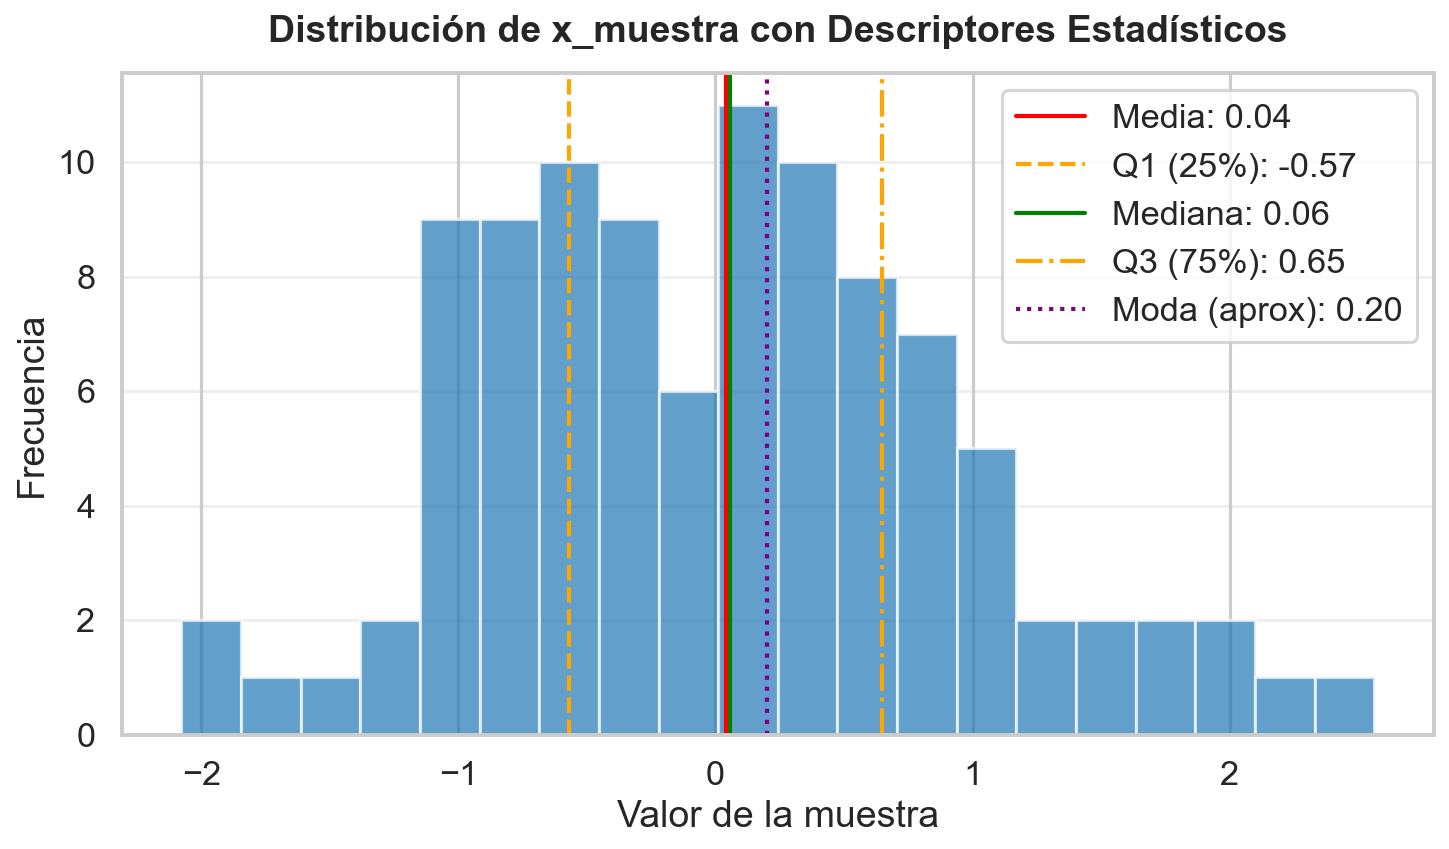

In [37]:
# Cálculo de estadísticos
media = np.mean(x_muestra)
q1 = np.percentile(x_muestra, 25)
mediana = np.median(x_muestra)
q3 = np.percentile(x_muestra, 75)

# Moda aproximada para datos continuos (redondeando a 1 decimal para simplificar)
# Usando scipy.stats que fue importado como stats
moda_resultado = stats.mode(np.round(x_muestra, 1), keepdims=True)
moda = moda_resultado.mode[0]

# Generación del gráfico (Histograma como base)
plt.figure(figsize=(10, 6), dpi=150)
plt.hist(x_muestra, bins=20, color='tab:blue', alpha=0.7, edgecolor='white')

# Añadir líneas verticales para cada estadístico
plt.axvline(media, color='red', linestyle='-', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(q1, color='orange', linestyle='--', linewidth=2, label=f'Q1 (25%): {q1:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(q3, color='orange', linestyle='-.', linewidth=2, label=f'Q3 (75%): {q3:.2f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda (aprox): {moda:.2f}')

# Detalles estéticos y etiquetas
plt.title('Distribución de x_muestra con Descriptores Estadísticos', pad=15, fontweight='bold')
plt.xlabel('Valor de la muestra')
plt.ylabel('Frecuencia')
plt.legend(frameon=True, loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()